In [64]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
import pickle

import warnings
warnings.filterwarnings('ignore')

In [36]:
car = pd.read_csv(r"C:\Users\harin\Desktop\Python Programming\Assignment\cardekho_imputated (1).csv")
car

,Unnamed: 0,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,19537,Hyundai i10,Hyundai,i10,9,10723,Dealer,Petrol,Manual,19.81,1086,68.05,5,250000
15407,19540,Maruti Ertiga,Maruti,Ertiga,2,18000,Dealer,Petrol,Manual,17.50,1373,91.10,7,925000
15408,19541,Skoda Rapid,Skoda,Rapid,6,67000,Dealer,Diesel,Manual,21.14,1498,103.52,5,425000
15409,19542,Mahindra XUV500,Mahindra,XUV500,5,3800000,Dealer,Diesel,Manual,16.00,2179,140.00,7,1225000


In [37]:
car.shape

(15411, 14)

In [38]:
car.isna().sum()

Unnamed: 0           0
car_name             0
brand                0
model                0
vehicle_age          0
km_driven            0
seller_type          0
fuel_type            0
transmission_type    0
mileage              0
engine               0
max_power            0
seats                0
selling_price        0
dtype: int64

In [39]:
car.nunique()

Unnamed: 0           15411
car_name               121
brand                   32
model                  120
vehicle_age             24
km_driven             3688
seller_type              3
fuel_type                5
transmission_type        2
mileage                411
engine                 110
max_power              342
seats                    8
selling_price         1086
dtype: int64

In [40]:
car.drop(columns=['seller_type','Unnamed: 0','car_name','model','seats'], inplace = True)
car

,brand,vehicle_age,km_driven,fuel_type,transmission_type,mileage,engine,max_power,selling_price
0,Maruti,9,120000,Petrol,Manual,19.70,796,46.30,120000
1,Hyundai,5,20000,Petrol,Manual,18.90,1197,82.00,550000
2,Hyundai,11,60000,Petrol,Manual,17.00,1197,80.00,215000
3,Maruti,9,37000,Petrol,Manual,20.92,998,67.10,226000
4,Ford,6,30000,Diesel,Manual,22.77,1498,98.59,570000
...,...,...,...,...,...,...,...,...,...
15406,Hyundai,9,10723,Petrol,Manual,19.81,1086,68.05,250000
15407,Maruti,2,18000,Petrol,Manual,17.50,1373,91.10,925000
15408,Skoda,6,67000,Diesel,Manual,21.14,1498,103.52,425000
15409,Mahindra,5,3800000,Diesel,Manual,16.00,2179,140.00,1225000


In [6]:
car.shape

(15411, 9)

In [7]:
car.nunique()

vehicle_age            24
km_driven            3688
fuel_type               5
transmission_type       2
mileage               411
engine                110
max_power             342
seats                   8
selling_price        1086
dtype: int64

In [42]:
car_selling = pd.get_dummies(car, columns=['brand', 'fuel_type', 'transmission_type'], drop_first=True)
car_selling

,vehicle_age,km_driven,mileage,engine,max_power,selling_price,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,...,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,120000,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,550000,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,215000,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,226000,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,570000,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15406,9,10723,19.81,1086,68.05,250000,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
15407,2,18000,17.50,1373,91.10,925000,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
15408,6,67000,21.14,1498,103.52,425000,False,False,False,False,...,True,False,False,False,False,True,False,False,False,True
15409,5,3800000,16.00,2179,140.00,1225000,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [14]:
car_selling.nunique()

vehicle_age                   24
km_driven                   3688
mileage                      411
engine                       110
max_power                    342
seats                          8
selling_price               1086
fuel_type_Diesel               2
fuel_type_Electric             2
fuel_type_LPG                  2
fuel_type_Petrol               2
transmission_type_Manual       2
dtype: int64

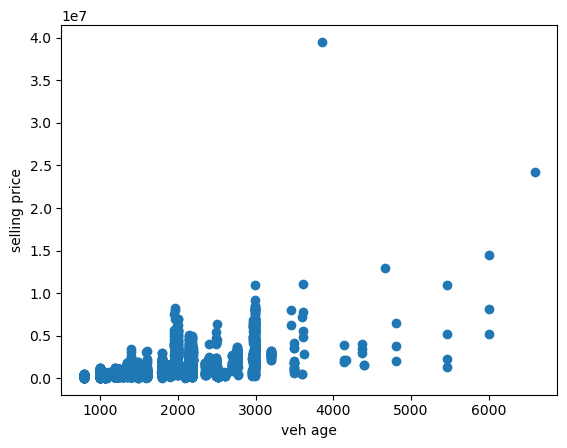

In [18]:
plt.scatter(car_selling['engine'],car['selling_price'])
plt.xlabel('veh age')
plt.ylabel('selling price')
plt.show()

In [44]:
x= car_selling.drop('selling_price', axis = 1)
y= car_selling['selling_price']

In [45]:
x.head()

,vehicle_age,km_driven,mileage,engine,max_power,brand_BMW,brand_Bentley,brand_Datsun,brand_Ferrari,brand_Force,...,brand_Skoda,brand_Tata,brand_Toyota,brand_Volkswagen,brand_Volvo,fuel_type_Diesel,fuel_type_Electric,fuel_type_LPG,fuel_type_Petrol,transmission_type_Manual
0,9,120000,19.70,796,46.30,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
1,5,20000,18.90,1197,82.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
2,11,60000,17.00,1197,80.00,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
3,9,37000,20.92,998,67.10,False,False,False,False,False,...,False,False,False,False,False,False,False,False,True,True
4,6,30000,22.77,1498,98.59,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,True


In [46]:
y.head()

0    120000
1    550000
2    215000
3    226000
4    570000
Name: selling_price, dtype: int64

In [47]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,shuffle=True, random_state=0)
print(x_train,x_test,y_train,y_test)

       vehicle_age  km_driven  mileage  engine  max_power  brand_BMW  \
14557            5      80634    18.00    1497      117.3      False   
9069            12      70000    20.36    1197       78.9      False   
4546             5      70000    25.32    1198       77.0      False   
14105            2      25000    21.21    1197       81.8      False   
14675            4     105000    21.72    1498      108.6      False   
...            ...        ...      ...     ...        ...        ...   
13123            6      39838    16.00    2179      140.0      False   
3264             2      37095    24.30    1248       88.5      False   
9845            12      68000    17.50    1298       85.8      False   
10799           11      65000    17.00    1497      118.0      False   
2732             4      61000    15.40    1997      120.0      False   

       brand_Bentley  brand_Datsun  brand_Ferrari  brand_Force  ...  \
14557          False         False          False        False  

In [28]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((12328, 11), (3083, 11), (12328,), (3083,))

In [61]:
mlr = LinearRegression()
mlr.fit(x_train,y_train)
y_train_pred = mlr.predict(x_train)
y_test_pred = mlr.predict(x_test)


In [63]:
train_acc = r2_score(y_train , y_train_pred)
test_acc = r2_score(y_test, y_test_pred)
print("train accuracy", train_acc*100,"%")
print("test accuracy", test_acc*100,"%")

train accuracy 79.46905897246495 %
test accuracy 76.29313755675044 %


In [65]:
pickle_out = open("model.pkl","wb")
pickle.dump(mlr,pickle_out)
pickle_out.close()